# L6 lab 2 · Derive and test variance propagation

For $z = w_1x_1 + ··· + w_nx_n$, independent zero-mean inputs and weights give

$$Var(z)=n · Var(w) · Var(x).$$

The goal is to **predict, calculate, run, inspect, and explain** one persistent case: a five-layer, width-4 ReLU chain. The notebook uses only NumPy and Matplotlib; it downloads no data.

## 1. Predict and calculate the anchor

Let the width be $n=4$, the depth be $L=5$, and set the boundary gauges $q_0=g_5=1$. Here

- $q_\ell=E[h_\ell^2]$ is the per-coordinate activation squared second moment;
- $g_\ell=E[(\partial\mathcal L/\partial h_\ell)^2]$ is the per-coordinate gradient squared second moment.

They are **squared gauges, not RMS values or total vector norms**. With a half-active ReLU, predict the one-layer multiplier

$$c=0.5\,n\,Var(w)$$

for Xavier $Var(w)=1/4$ and He $Var(w)=2/4=0.5$. Then predict $c^5$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

WIDTH, DEPTH, TRIALS = 4, 5, 100_000
Q0 = G5 = 1.0
RELU_GATE = 0.5
schemes = {
    "Xavier": 1 / WIDTH,
    "He": 2 / WIDTH,
}

multipliers = {
    name: RELU_GATE * WIDTH * var_w
    for name, var_w in schemes.items()
}

print(f"anchor: width={WIDTH}, layers={DEPTH}, q0={Q0:g}, g5={G5:g}")
for name, var_w in schemes.items():
    c = multipliers[name]
    print(f"{name:7s}: Var(w)={var_w:g}, c={c:g}, c^5={c**DEPTH:g}")

assert schemes == {"Xavier": 0.25, "He": 0.5}
assert multipliers == {"Xavier": 0.5, "He": 1.0}
assert multipliers["Xavier"]**DEPTH == 0.03125

anchor: width=4, layers=5, q0=1, g5=1
Xavier : Var(w)=0.25, c=0.5, c^5=0.03125
He     : Var(w)=0.5, c=1, c^5=1


## 2. Run an independent one-layer check

Before running, expect the empirical post-ReLU squared gauge to be near $q_1=cq_0$: $0.5$ for Xavier and $1$ for He. Every trial draws fresh width-4 inputs and weights, so this checks the expectation used in the ledger rather than one unusually lucky matrix.

In [2]:
rng = np.random.default_rng(6)
x = rng.standard_normal((TRIALS, WIDTH))
rows = []
for name, var_w in schemes.items():
    w = rng.normal(0, np.sqrt(var_w), (TRIALS, WIDTH))
    z = np.sum(w*x, axis=1)
    h = np.maximum(0, z)
    pred_z2 = WIDTH * var_w * Q0
    pred_h2 = multipliers[name] * Q0
    rows.append((name, pred_z2, np.mean(z**2), pred_h2, np.mean(h**2)))

print(f"{'scheme':8s} {'pred E[z²]':>12s} {'emp E[z²]':>12s} {'pred q1':>10s} {'emp q1':>10s}")
for row in rows:
    print(f"{row[0]:8s} {row[1]:12.4f} {row[2]:12.4f} {row[3]:10.4f} {row[4]:10.4f}")

assert all(abs(emp_z2/pred_z2 - 1) < 0.03 for _, pred_z2, emp_z2, _, _ in rows)
assert all(abs(emp_h2/pred_h2 - 1) < 0.03 for _, _, _, pred_h2, emp_h2 in rows)

scheme     pred E[z²]    emp E[z²]    pred q1     emp q1
Xavier         1.0000       0.9963     0.5000     0.4960
He             2.0000       2.0320     1.0000     1.0278


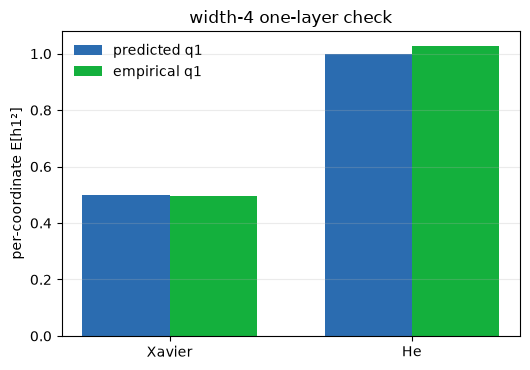

In [3]:
labels = [row[0] for row in rows]
pred_q1 = np.array([row[3] for row in rows])
emp_q1 = np.array([row[4] for row in rows])
positions = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(5.4, 3.8))
ax.bar(positions - 0.18, pred_q1, 0.36, label='predicted q1', color='#2B6CB0')
ax.bar(positions + 0.18, emp_q1, 0.36, label='empirical q1', color='#14B03D')
ax.set(xticks=positions, xticklabels=labels, ylabel='per-coordinate E[h1²]', title='width-4 one-layer check')
ax.grid(axis='y', alpha=.25); ax.legend(frameon=False); plt.tight_layout(); plt.show()

## 3. Inspect the five-layer depth ledger

Under the same independence and half-active assumptions, the squared gauges obey

$$q_\ell=c^\ell q_0, \qquad g_\ell=c^{5-\ell}g_5.$$

Predict the two endpoints $q_5$ and $g_0$ for each scheme, then inspect every indexed layer. Because these are squared gauges, an RMS ratio would be their square root.

layer | Xavier q_l | Xavier g_l | He q_l | He g_l
    0 |           1 |     0.03125 |      1 |      1
    1 |         0.5 |      0.0625 |      1 |      1
    2 |        0.25 |       0.125 |      1 |      1
    3 |       0.125 |        0.25 |      1 |      1
    4 |      0.0625 |         0.5 |      1 |      1
    5 |     0.03125 |           1 |      1 |      1
Xavier endpoints: q5=0.03125, g0=0.03125
He endpoints:     q5=1, g0=1


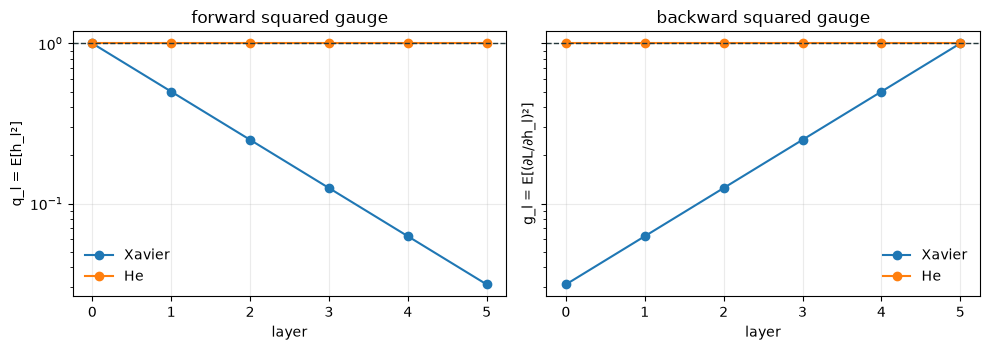

In [4]:
layers = np.arange(DEPTH + 1)
ledger = {}
for name, c in multipliers.items():
    q = Q0 * c**layers
    g = G5 * c**(DEPTH - layers)
    ledger[name] = (q, g)

print("layer | Xavier q_l | Xavier g_l | He q_l | He g_l")
for layer in layers:
    xq, xg = ledger["Xavier"]
    hq, hg = ledger["He"]
    print(f"{layer:5d} | {xq[layer]:11g} | {xg[layer]:11g} | {hq[layer]:6g} | {hg[layer]:6g}")

print(f"Xavier endpoints: q5={ledger['Xavier'][0][-1]:g}, g0={ledger['Xavier'][1][0]:g}")
print(f"He endpoints:     q5={ledger['He'][0][-1]:g}, g0={ledger['He'][1][0]:g}")

assert np.array_equal(ledger["Xavier"][0], [1, .5, .25, .125, .0625, .03125])
assert np.array_equal(ledger["Xavier"][1], [.03125, .0625, .125, .25, .5, 1])
assert np.array_equal(ledger["He"][0], np.ones(DEPTH + 1))
assert np.array_equal(ledger["He"][1], np.ones(DEPTH + 1))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for name, (q, g) in ledger.items():
    axes[0].semilogy(layers, q, marker='o', label=name)
    axes[1].semilogy(layers, g, marker='o', label=name)
axes[0].set(title='forward squared gauge', xlabel='layer', ylabel='q_l = E[h_l²]')
axes[1].set(title='backward squared gauge', xlabel='layer', ylabel='g_l = E[(∂L/∂h_l)²]')
for ax in axes:
    ax.axhline(1, ls='--', lw=1, color='#23373B')
    ax.grid(alpha=.25); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 4. Explain the assumptions

Answer these before moving on:

- Why do cross-covariance terms disappear in the derivation?
- Why do we track $E[h^2]$ rather than calling it exactly $Var(h)$ after ReLU?
- Why is $c^5=0.03125$ a squared-gauge ratio rather than an RMS ratio or total norm?
- Which assumptions become less accurate after training creates correlations?

**Takeaway:** with $q_0=g_5=1$, Xavier at width 4 has $Var(w)=1/4$, $c=0.5$, and $q_5=g_0=0.03125$; He has $Var(w)=0.5$, $c=1$, and both endpoints remain 1. Initialization is an approximate starting-scale calculation, so the next lab also measures actual RMS traces.